<a href="https://www.kaggle.com/code/tasniaesha6322/plantgvit-graph-augmented-vision-transformer-for?scriptVersionId=337884921" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1: Unified Library Declarations

In [1]:
# ==============================================================================
# CELL 1: UNIFIED LIBRARY DECLARATIONS, CONFIGURATION & SEED SETTING
# ==============================================================================
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Configurations
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# Set Seed for Reproducibility
# ------------------------------------------------------------------------------
SEED = 42

def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(SEED)

print(f"Seed set to: {SEED}")
print(f"TensorFlow Version: {tf.__version__}")
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

Seed set to: 42
TensorFlow Version: 2.20.0
GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# 2: Dataset Download and Automatic Path Locator

In [2]:
# ==============================================================================
# CELL 2: DATASET DOWNLOAD & PATH DISCOVERY
# ==============================================================================
import kagglehub

# Download or locate dataset
path = kagglehub.dataset_download("imranshikder123/plantcity")
print("Path to dataset files:", path)

# Auto-discover directory containing 52 classes
data_dir = None
for root, dirs, files in os.walk(path):
    if len(dirs) == 52:
        data_dir = root
        break

if data_dir is None:
    all_dirs = [d for d in glob.glob(os.path.join(path, '**'), recursive=True) if os.path.isdir(d)]
    if all_dirs:
        data_dir = max(all_dirs, key=lambda d: len(os.listdir(d)))

# Verify that the directory path exists
if not data_dir or not os.path.exists(data_dir):
    raise FileNotFoundError("Valid dataset directory not found! Please check the path.")

print(f"Finalized Training Data Directory: {data_dir}")

Path to dataset files: /kaggle/input/datasets/imranshikder123/plantcity
Finalized Training Data Directory: /kaggle/input/datasets/imranshikder123/plantcity/PlantCity A Comprehensive Image Based on Multi Cro/Images/test/test


# 3: EDA - Species and Classes Statistics

Total verified classes: 52
Total images counted: 10667


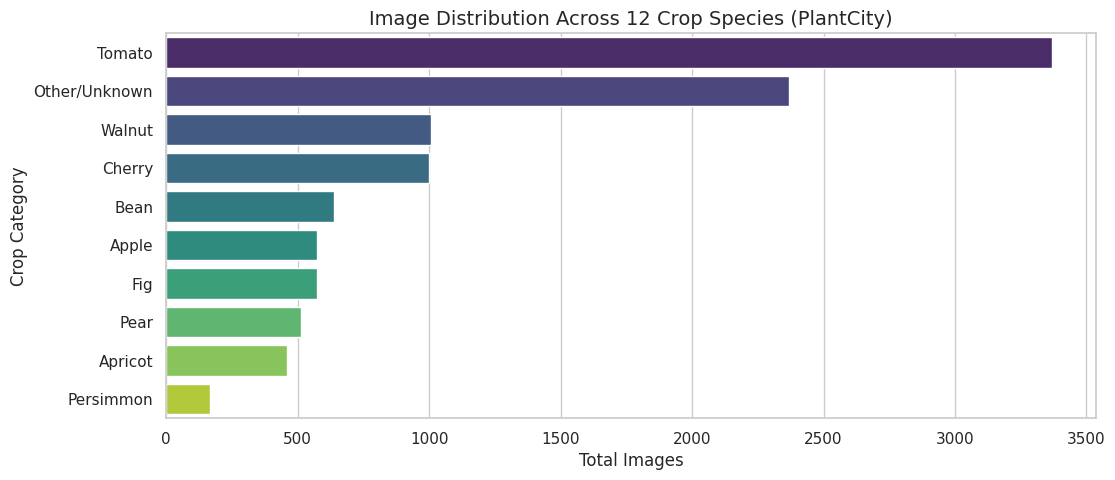

In [3]:
# ==============================================================================
# CELL 3: EDA - CLASS AND CROP SPECIES DISTRIBUTION
# ==============================================================================
class_list = sorted(os.listdir(data_dir))
dataset_records = []

for c in class_list:
    class_path = os.path.join(data_dir, c)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        dataset_records.append({'Class_Name': c, 'Image_Count': num_images})

df_eda = pd.DataFrame(dataset_records)

# Define 12 main crops
crops_supported = ['Apple', 'Apricot', 'Bean', 'Cherry', 'Maize', 'Fig', 'Grapes', 'Loquat', 'Pear', 'Tomato', 'Walnut', 'Persimmon']

def identify_crop(class_name):
    for crop in crops_supported:
        if crop.lower() in class_name.lower():
            return crop
    return "Other/Unknown"

df_eda['Crop_Species'] = df_eda['Class_Name'].apply(identify_crop)

print(f"Total verified classes: {len(df_eda)}")
print(f"Total images counted: {df_eda['Image_Count'].sum()}")

# Visualizing Crop Species Sample Distribution
plt.figure(figsize=(12, 5))
crop_counts = df_eda.groupby('Crop_Species')['Image_Count'].sum().sort_values(ascending=False)
sns.barplot(x=crop_counts.values, y=crop_counts.index, palette="viridis")
plt.title("Image Distribution Across 12 Crop Species (PlantCity)", fontsize=14)
plt.xlabel("Total Images")
plt.ylabel("Crop Category")
plt.show()

# 4: Clean EDA Visualization Pipeline (VDE - Balanced Multi-Sample Grid)

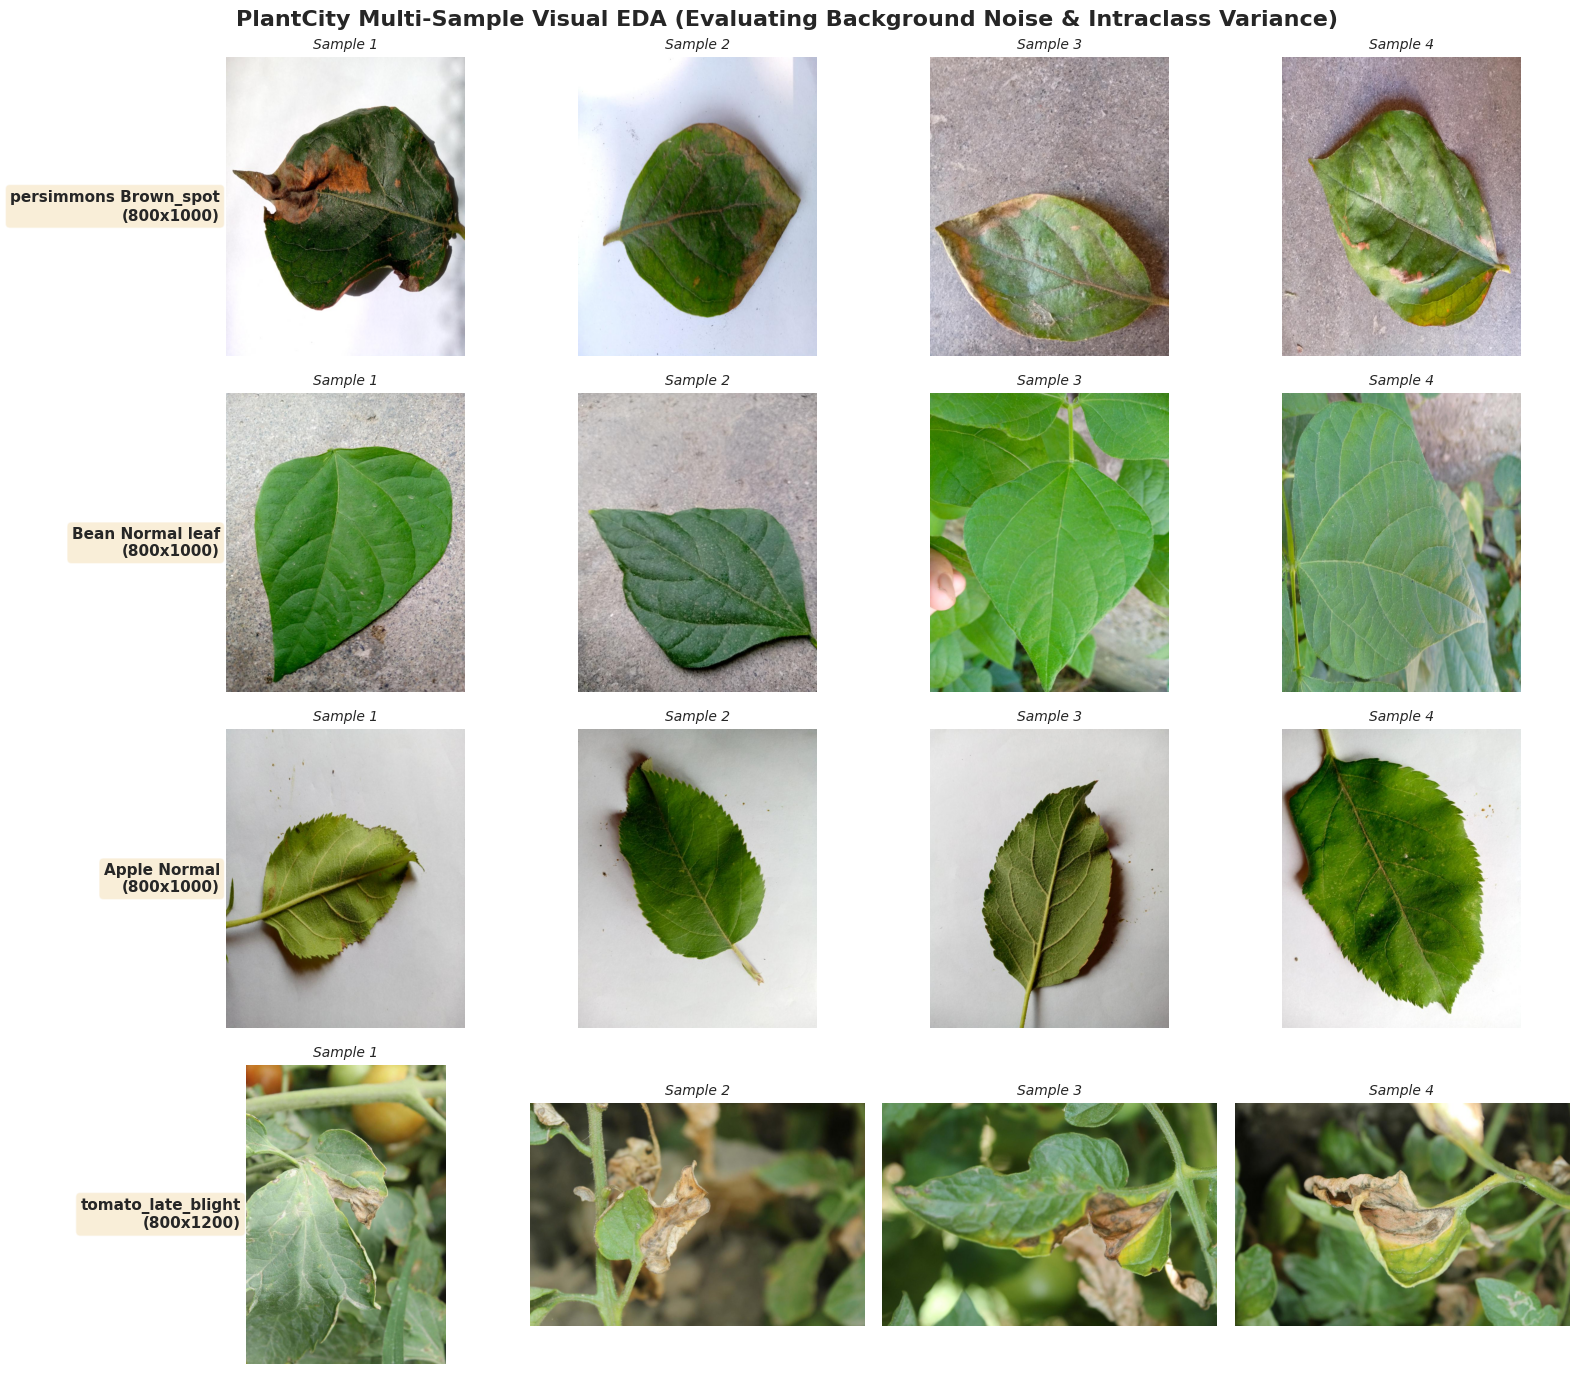

In [4]:
# ==============================================================================
# CELL 4: VISUAL DATA EXPLORATION (VDE) - MULTI-SAMPLE BALANCED GRID
# ==============================================================================
NUM_CLASSES_TO_SHOW = 4
SAMPLES_PER_CLASS = 4

unique_classes_available = df_eda['Class_Name'].unique()
random.seed(42)  # For reproducibility
selected_classes = random.sample(list(unique_classes_available), NUM_CLASSES_TO_SHOW)

fig, axes = plt.subplots(
    nrows=NUM_CLASSES_TO_SHOW, 
    ncols=SAMPLES_PER_CLASS, 
    figsize=(4 * SAMPLES_PER_CLASS, 3.5 * NUM_CLASSES_TO_SHOW)
)

for row_idx, class_name in enumerate(selected_classes):
    class_folder = os.path.join(data_dir, class_name)
    all_images_in_class = [img for img in os.listdir(class_folder) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sampled_image_names = random.sample(all_images_in_class, SAMPLES_PER_CLASS)
    
    for col_idx, img_name in enumerate(sampled_image_names):
        img_path = os.path.join(class_folder, img_name)
        ax = axes[row_idx, col_idx]
        
        with Image.open(img_path) as img:
            img_array = np.array(img)
            width, height = img.size
            
        ax.imshow(img_array)
        ax.axis('off')
        
        if col_idx == 0:
            ax.text(
                -20, height // 2, f"{class_name}\n({width}x{height})", 
                rotation=0, va='center', ha='right', fontsize=11, 
                weight='bold', bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
            )
        ax.set_title(f"Sample {col_idx + 1}", fontsize=10, style='italic')

plt.suptitle("PlantCity Multi-Sample Visual EDA (Evaluating Background Noise & Intraclass Variance)", fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()
    
    



    
        


# **5: Enable Mixed Precision & Dataset SetupPython**


In [5]:
# ==============================================================================
# CELL 5: DATA PIPELINE OPTIMIZATION, MIXED PRECISION & CLASS WEIGHTS
# ==============================================================================
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import mixed_precision
from sklearn.utils.class_weight import compute_class_weight

# GPU Performance বাড়ানোর জন্য Mixed Precision চালু করা
mixed_precision.set_global_policy('mixed_float16')

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Building Train Split...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("Building Validation Split...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

NUM_CLASSES = len(train_dataset.class_names)
class_labels = train_dataset.class_names

# Class Weight Calculation
train_labels = []
for idx, class_name in enumerate(class_labels):
    class_path = os.path.join(data_dir, class_name)
    num_images = len(os.listdir(class_path))
    train_labels.extend([idx] * num_images)

train_labels = np.array(train_labels)
classes_unique = np.unique(train_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes_unique,
    y=train_labels
)
class_weight_dict = dict(zip(classes_unique, class_weights))

# Data pipeline optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(buffer_size=1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(f"\nData pipeline configured for {NUM_CLASSES} classes with mixed precision enabled.")
print("Class weights successfully generated!")

Building Train Split...
Found 10667 files belonging to 52 classes.
Using 8534 files for training.


I0000 00:00:1784990985.510038      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784990985.512821      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Building Validation Split...
Found 10667 files belonging to 52 classes.
Using 2133 files for validation.

Data pipeline configured for 52 classes with mixed precision enabled.
Class weights successfully generated!


# **5B: Unified Baseline Architecture**

In [6]:
# ==============================================================================
# CELL 5B: UNIFIED BASELINE ARCHITECTURE FUNCTION
# ==============================================================================
from tensorflow.keras.applications import MobileNetV2, ResNet50V2
from tensorflow.keras import layers, Model

def build_baseline_cnn(model_type="mobilenet", num_classes=52, img_size=(224, 224)):
    inputs = layers.Input(shape=(img_size[0], img_size[1], 3))
    
    if model_type.lower() == "mobilenet":
        # MobileNetV2 requires [-1, 1] scaling
        x = layers.Rescaling(scale=1./127.5, offset=-1)(inputs)
        base_model = MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')
        model_name = "Baseline_MobileNetV2"
        
    elif model_type.lower() == "resnet":
        # ResNet50V2 requires [-1, 1] scaling
        x = layers.Rescaling(scale=1./127.5, offset=-1)(inputs)
        base_model = ResNet50V2(input_tensor=x, include_top=False, weights='imagenet')
        model_name = "Baseline_ResNet50V2"
        
    else:
        raise ValueError("Unsupported model_type! Choose 'mobilenet' or 'resnet'.")
    
    # Pretrained Base Model-এর Weight Freeze রাখা হচ্ছে
    base_model.trainable = False  
    
    # Classification Head
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.3)(x)
    
    # Mixed precision সাপোর্ট নিশ্চিত করতে Output layer-এ float32 ব্যবহার করা হয়েছে
    outputs = layers.Dense(num_classes, activation="softmax", dtype='float32')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name=model_name)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Unified Baseline Architecture Function initialized successfully!")

Unified Baseline Architecture Function initialized successfully!


# **5C: MobileNetV2 Training (20 Ephoc)**

In [7]:
# ==============================================================================
# CELL 5C: MOBILENETV2 TRAINING (20 EPOCHS)
# ==============================================================================
print("1. Initializing MobileNetV2 Baseline Model...")
mobilenet_model = build_baseline_cnn(model_type="mobilenet", num_classes=NUM_CLASSES)
mobilenet_model.summary()

# Callbacks
mobilenet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("\n2. Starting MobileNetV2 Training for 20 Epochs...")
mobilenet_history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=mobilenet_callbacks,
    class_weight=class_weight_dict  # <-- Class Weight Added Here
)

1. Initializing MobileNetV2 Baseline Model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Baseline_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis

 Total params: 2,324,596 (8.87 MB)

 Trainable params: 66,612 (260.20 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


2. Starting MobileNetV2 Training for 20 Epochs...
Epoch 1/20


I0000 00:00:1784991046.686995      79 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


267/267 ━━━━━━━━━━━━━━━━━━━━ 138s 279ms/step - accuracy: 0.5771 - loss: 1.6243 - val_accuracy: 0.7914 - val_loss: 0.7392 - learning_rate: 0.0010
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8224 - loss: 0.6120 - val_accuracy: 0.8490 - val_loss: 0.5368 - learning_rate: 0.0010
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8677 - loss: 0.4266 - val_accuracy: 0.8636 - val_loss: 0.4516 - learning_rate: 0.0010
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8938 - loss: 0.3367 - val_accuracy: 0.8800 - val_loss: 0.4002 - learning_rate: 0.0010
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9122 - loss: 0.2733 - val_accuracy: 0.8959 - val_loss: 0.3532 - learning_rate: 0.0010
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9242 - loss: 0.2371 - val_accuracy: 0.8908 - val_loss: 0.3658 - learning_rate: 0.0010
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9365 - loss: 0.1998 - v

# ** 5D:ResNet50V2 Training (20 Epochs)**

In [8]:
# ==============================================================================
# CELL 5D: RESNET50V2 TRAINING (20 EPOCHS)
# ==============================================================================
print("1. Initializing ResNet50V2 Baseline Model...")
resnet_model = build_baseline_cnn(model_type="resnet", num_classes=NUM_CLASSES)
resnet_model.summary()

# Callbacks
resnet_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("\n2. Starting ResNet50V2 Training for 20 Epochs...")
resnet_history = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=resnet_callbacks,
    class_weight=class_weight_dict  # <-- Class Weight Added Here
)

1. Initializing ResNet50V2 Baseline Model...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "Baseline_ResNet50V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r

 Total params: 23,671,348 (90.30 MB)

 Trainable params: 106,548 (416.20 KB)

 Non-trainable params: 23,564,800 (89.89 MB)


2. Starting ResNet50V2 Training for 20 Epochs...
Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 43s 104ms/step - accuracy: 0.5275 - loss: 1.7160 - val_accuracy: 0.7726 - val_loss: 0.8681 - learning_rate: 0.0010
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7925 - loss: 0.6957 - val_accuracy: 0.8261 - val_loss: 0.6573 - learning_rate: 0.0010
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8514 - loss: 0.4853 - val_accuracy: 0.8354 - val_loss: 0.5687 - learning_rate: 0.0010
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8854 - loss: 0.3830 - val_accuracy: 0.8533 - val_loss: 0.5111 - learning_rate: 0.0010
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9022 - loss: 0.3152 - val_accuracy: 0.8626 - val_loss: 0.4785 - learning_rate: 0.0010
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9222 - loss: 0.2615 - val_accuracy: 0.8650 - val_loss: 0.4623 - learning_rate: 0.0010
Epoch 7/20
267/267 ━━━━━━━━━━━

# 6: Custom PlantGViT Architecture Components

In [9]:
# ==============================================================================
# CELL 6: CUSTOM PLANTGVIT MODULE DEFINITIONS
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers

class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super(PatchEmbedding, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.projection = layers.Conv2D(
            filters=embed_dim, 
            kernel_size=patch_size, 
            strides=patch_size, 
            padding="valid",
            name="patch_conv_projection"
        )
        self.flatten = layers.Reshape((-1, embed_dim))
        
    def build(self, input_shape):
        num_patches = (input_shape[1] // self.patch_size) * (input_shape[2] // self.patch_size)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=self.embed_dim
        )
        self.num_patches = num_patches
        super(PatchEmbedding, self).build(input_shape)
        
    def call(self, images):
        x = self.projection(images)
        x = self.flatten(x)
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return x + self.position_embedding(positions)

class GraphConvolution(layers.Layer):
    def __init__(self, units, **kwargs):
        super(GraphConvolution, self).__init__(**kwargs)
        self.projection = layers.Dense(units, activation="relu")
        
    def call(self, node_features):
        dot_product = tf.matmul(node_features, node_features, transpose_b=True)
        adj = tf.nn.softmax(dot_product, axis=-1) 
        projected = self.projection(node_features)
        return tf.matmul(adj, projected)

class PlantGViTBlock(layers.Layer):
    def __init__(self, projection_dim, num_heads, transformer_units, **kwargs):
        super(PlantGViTBlock, self).__init__(**kwargs)
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)
        
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.gcn = GraphConvolution(projection_dim)
        
        self.ln3 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp_dense1 = layers.Dense(transformer_units, activation="gelu")
        self.mlp_drop1 = layers.Dropout(0.2)
        self.mlp_dense2 = layers.Dense(projection_dim)
        self.mlp_drop2 = layers.Dropout(0.2)
        
    def call(self, inputs):
        # 1. Attention
        x1 = self.ln1(inputs)
        attention_output = self.mha(x1, x1)
        x2 = inputs + attention_output
        
        # 2. Graph Module
        x3 = self.ln2(x2)
        gcn_output = self.gcn(x3)
        x4 = x2 + gcn_output
        
        # 3. MLP
        x5 = self.ln3(x4)
        mlp_out = self.mlp_dense1(x5)
        mlp_out = self.mlp_drop1(mlp_out)
        mlp_out = self.mlp_dense2(mlp_out)
        mlp_out = self.mlp_drop2(mlp_out)
        
        return x4 + mlp_out

# 7: Building and Compiling PlantGViT

In [10]:
# ==============================================================================
# CELL 7: PLANTGVIT MODEL BUILDER (BUG FIX + SCALING)
# ==============================================================================
def build_plant_gvit(num_classes, img_size=224, patch_size=16, projection_dim=128, num_heads=4, transformer_units=256):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    
    # 1. Rescaling (0 to 1) & Data Augmentation Layers
    x = layers.Rescaling(1./255)(inputs)
    x = layers.RandomFlip("horizontal_and_vertical")(x)
    x = layers.RandomRotation(0.15)(x)
    
    # 2. Patch & Position Embedding
    encoded_patches = PatchEmbedding(patch_size, projection_dim)(x)
    
    # 3. Transformer + Graph Blocks
    x = PlantGViTBlock(projection_dim, num_heads, transformer_units)(encoded_patches)
    x = PlantGViTBlock(projection_dim, num_heads, transformer_units)(x)
    
    # 4. Pooling & Output Head
    representation = layers.LayerNormalization(epsilon=1e-6)(x)
    representation = layers.GlobalAveragePooling1D()(representation)
    representation = layers.Dropout(0.3)(representation)
    
    # Float32 output requirement for mixed precision stability
    outputs = layers.Dense(num_classes, activation="softmax", dtype='float32')(representation)
    
    model = Model(inputs=inputs, outputs=outputs, name="PlantGViT_Model")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

plant_gvit_model = build_plant_gvit(num_classes=NUM_CLASSES)
plant_gvit_model.summary()

Model: "PlantGViT_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, 196, 128)       │       123,520 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ plant_g_vi_t_block              │ (None, 196, 128)       │       347,008 │
│ (PlantGViTBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ plant_g_vi_t_block_1            │ (None, 196, 128)       │       347,008 │
│ (PlantGViTBlock)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_6           │ (None, 196, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 52)             │         6,708 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,500 (3.15 MB)

 Trainable params: 824,500 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

# 8: Model Training with Advanced Callbacks

In [11]:
# ==============================================================================
# CELL 8: EXTENDED MODEL TRAINING (50 EPOCHS)
# ==============================================================================
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=8,  # Increased patience for longer training stability
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-6,
    verbose=1
)

EPOCHS = 50  # Increased epochs as requested

print("Starting extended training on PlantGViT Framework...")
history = plant_gvit_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr]
)

Starting extended training on PlantGViT Framework...
Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.0564 - loss: 3.8495 - val_accuracy: 0.0947 - val_loss: 3.5466 - learning_rate: 0.0010
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.1255 - loss: 3.2067 - val_accuracy: 0.1992 - val_loss: 2.9505 - learning_rate: 0.0010
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.2278 - loss: 2.7916 - val_accuracy: 0.3366 - val_loss: 2.4323 - learning_rate: 0.0010
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.3383 - loss: 2.3152 - val_accuracy: 0.3999 - val_loss: 2.0971 - learning_rate: 0.0010
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.4148 - loss: 2.0185 - val_accuracy: 0.4388 - val_loss: 1.9160 - learning_rate: 0.0010
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.4607 - loss: 1.8307 - val_accuracy: 0.4435 - val_loss: 1.8360 - learning_rate: 0.0010
Epoch 7/50
267/267 ━━━━

# **Cell 9: Comprehensive Multi-Model Evaluation & Visualizations**

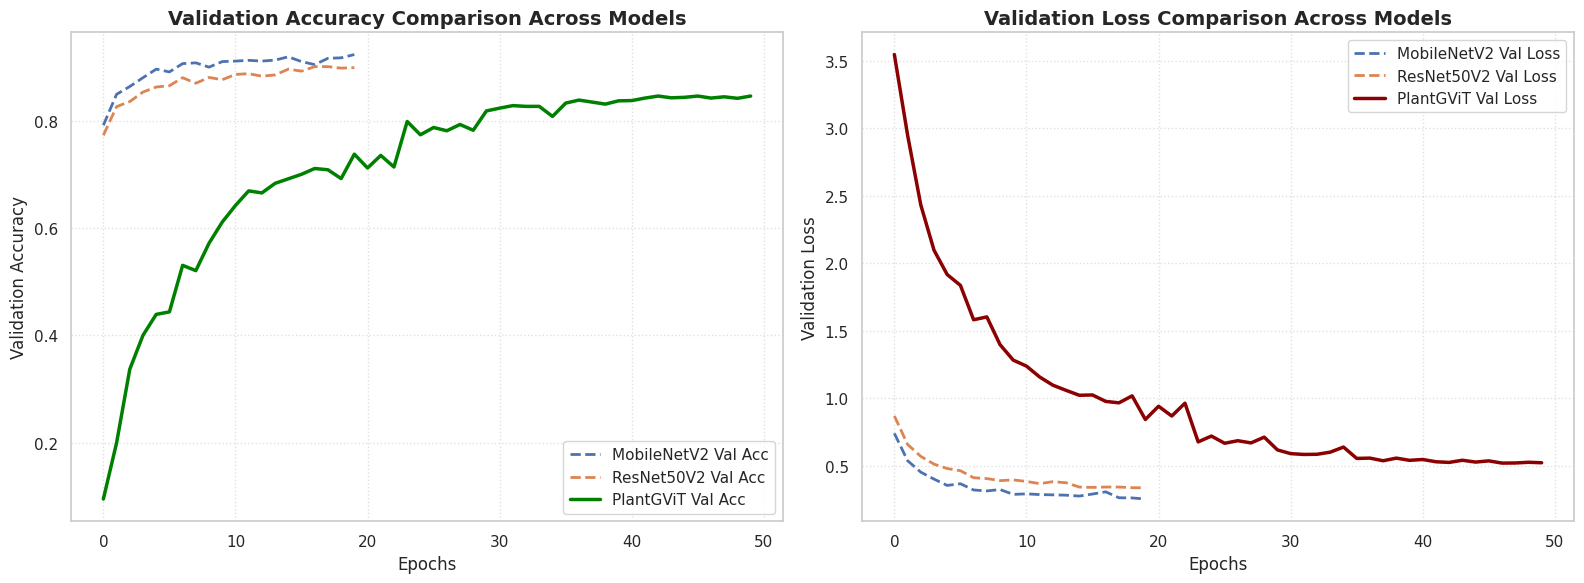

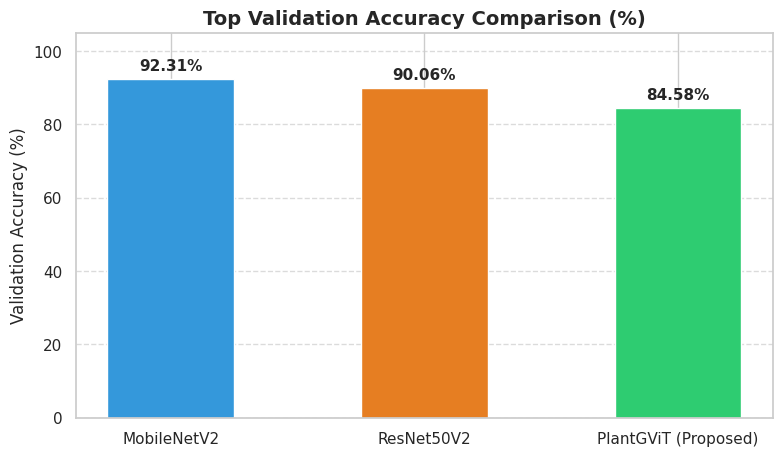


Extracting PlantGViT Model Predictions on Validation Dataset...


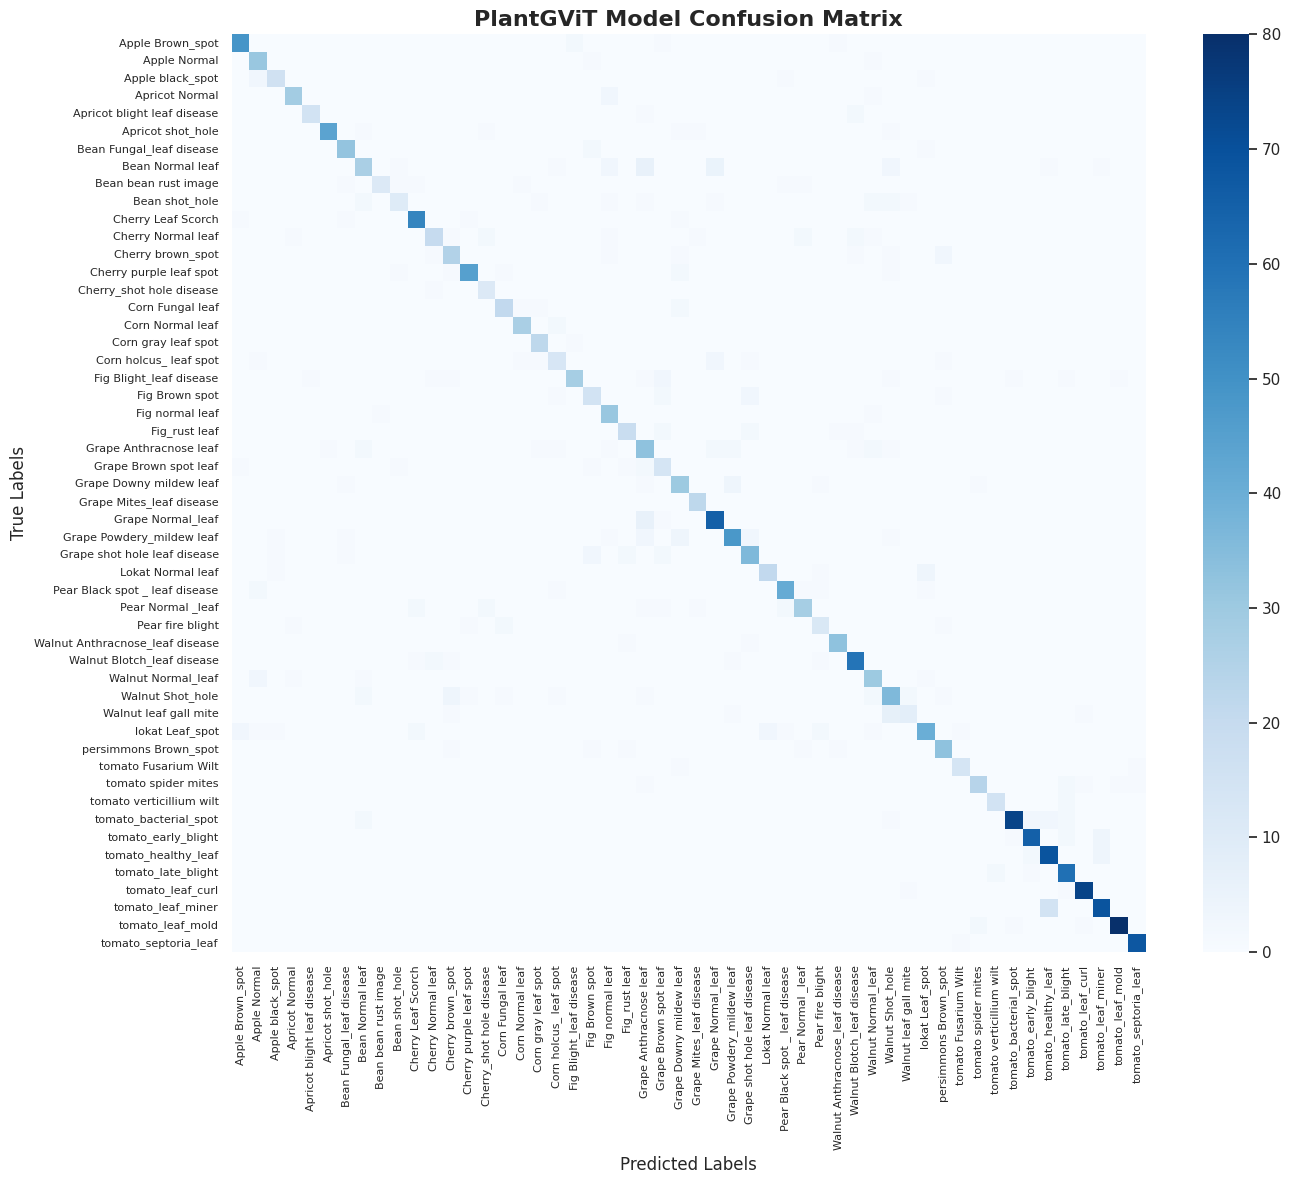


             PLANTGVIT CLASSIFICATION PERFORMANCE REPORT            
                                 precision    recall  f1-score   support

               Apple Brown_spot       0.91      0.92      0.92        53
                   Apple Normal       0.76      0.94      0.84        33
               Apple black_spot       0.80      0.76      0.78        21
                 Apricot Normal       0.91      0.88      0.89        33
    Apricot blight leaf disease       0.94      0.83      0.88        18
              Apricot shot_hole       0.98      0.90      0.94        49
       Bean Fungal_leaf disease       0.86      0.91      0.89        35
               Bean Normal leaf       0.73      0.56      0.64        48
           Bean bean rust image       0.92      0.65      0.76        17
                 Bean shot_hole       0.71      0.48      0.57        21
             Cherry Leaf Scorch       0.90      0.93      0.92        58
             Cherry Normal leaf       0.80      0.65 

In [12]:
# ==============================================================================
# CELL 9: COMPREHENSIVE MULTI-MODEL EVALUATION & VISUALIZATIONS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------------------------
# 1. VISUALIZING TRAINING & VALIDATION CURVES FOR ALL MODELS
# ------------------------------------------------------------------------------
plt.figure(figsize=(16, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(mobilenet_history.history['val_accuracy'], label='MobileNetV2 Val Acc', linestyle='--', lw=2)
plt.plot(resnet_history.history['val_accuracy'], label='ResNet50V2 Val Acc', linestyle='--', lw=2)
plt.plot(history.history['val_accuracy'], label='PlantGViT Val Acc', lw=2.5, color='green')
plt.title('Validation Accuracy Comparison Across Models', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(mobilenet_history.history['val_loss'], label='MobileNetV2 Val Loss', linestyle='--', lw=2)
plt.plot(resnet_history.history['val_loss'], label='ResNet50V2 Val Loss', linestyle='--', lw=2)
plt.plot(history.history['val_loss'], label='PlantGViT Val Loss', lw=2.5, color='darkred')
plt.title('Validation Loss Comparison Across Models', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 2. FINAL VALIDATION METRICS COMPARISON (BAR CHART)
# ------------------------------------------------------------------------------
mobilenet_best_acc = max(mobilenet_history.history['val_accuracy'])
resnet_best_acc = max(resnet_history.history['val_accuracy'])
gvit_best_acc = max(history.history['val_accuracy'])

model_names = ['MobileNetV2', 'ResNet50V2', 'PlantGViT (Proposed)']
acc_scores = [mobilenet_best_acc * 100, resnet_best_acc * 100, gvit_best_acc * 100]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, acc_scores, color=['#3498db', '#e67e22', '#2ecc71'], width=0.5)
plt.title('Top Validation Accuracy Comparison (%)', fontsize=14, fontweight='bold')
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.ylim(0, 105)

# Display Values on Top of Bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ------------------------------------------------------------------------------
# 3. EXTRACTION OF PLANTGVIT PREDICTIONS FOR DETAILED EVALUATION
# ------------------------------------------------------------------------------
print("\nExtracting PlantGViT Model Predictions on Validation Dataset...")
y_true_list = []
y_pred_list = []

for imgs, lbls in val_dataset:
    predictions = plant_gvit_model.predict(imgs, verbose=0)
    y_true_list.extend(np.argmax(lbls.numpy(), axis=1))
    y_pred_list.extend(np.argmax(predictions, axis=1))

# ------------------------------------------------------------------------------
# 4. CONFUSION MATRIX HEATMAP (PLANTGVIT)
# ------------------------------------------------------------------------------
cm = confusion_matrix(y_true_list, y_pred_list)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title('PlantGViT Model Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. CLASSIFICATION REPORT
# ------------------------------------------------------------------------------
print("\n" + "="*70)
print("             PLANTGVIT CLASSIFICATION PERFORMANCE REPORT            ")
print("="*70)
print(classification_report(y_true_list, y_pred_list, target_names=class_labels))